In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from pathlib import Path
import json
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm

from efficientnet_pytorch import EfficientNet

# Sklearn imports
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, 
                              confusion_matrix, classification_report, roc_auc_score, 
                              roc_curve)

# Grad-CAM
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Available VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Available VRAM: 8.59 GB


In [ ]:


CONFIG = {
    'data_root': 'ultrasound-fetus-dataset/', 
    'train_dir': 'ultrasound-fetus-dataset/train',
    'val_dir': 'ultrasound-fetus-dataset/validation',
    'test_dir': 'ultrasound-fetus-dataset/test',
    'pretrained_model_path': 'ultrasound-fetus-dataset/Resnet_fineTuning.pth',  
    'overlay_images_dir': 'ultrasound-fetus-dataset/OverlayedImages', 
    
    # Output paths
    'save_dir': './model1_outputs',
    'model_save_path': './model1_outputs/checkpoints',
    'logs_path': './model1_outputs/logs',
    
    'classes': ['benign', 'malignant', 'normal'],  # Alphabetical order
    'num_classes': 3,
    
    # Model settings
    'model_name': 'mobilenet_v2',
    'use_pretrained_resnet': True,  
    'freeze_backbone': False,  

    # Class balancing
    'balance_classes': True,
    'target_samples_per_class': 700,
    
    # Training settings
    'img_size': 224, 
    'batch_size': 16,  
    'num_epochs': 50,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,  
    'patience': 15,  # More patience with CosineAnnealing

    # Anti-overfitting settings
    'use_aggressive_augmentation': False,  # ENABLED - critical for small datasets
    'label_smoothing': 0.1,  # Prevents overconfident predictions
    'mixup_alpha': 0.3,  # MixUp augmentation strength (0 = disabled)
    
    # Mixed precision training
    'use_amp': True,  # Automatic Mixed Precision for faster training
    
    # Other settings
    'num_workers': 0,
    'pin_memory': True,
}

# Create directories
os.makedirs(CONFIG['save_dir'], exist_ok=True)
os.makedirs(CONFIG['model_save_path'], exist_ok=True)
os.makedirs(CONFIG['logs_path'], exist_ok=True)

print("=" * 80)

print("CONFIGURATION")
print(json.dumps(CONFIG, indent=2))
print("=" * 80)

CONFIGURATION
{
  "data_root": "ultrasound-fetus-dataset/",
  "train_dir": "ultrasound-fetus-dataset/train",
  "val_dir": "ultrasound-fetus-dataset/validation",
  "test_dir": "ultrasound-fetus-dataset/test",
  "pretrained_model_path": "ultrasound-fetus-dataset/Resnet_fineTuning.pth",
  "overlay_images_dir": "ultrasound-fetus-dataset/OverlayedImages",
  "save_dir": "./model1_outputs",
  "model_save_path": "./model1_outputs/checkpoints",
  "logs_path": "./model1_outputs/logs",
  "classes": [
    "benign",
    "malignant",
    "normal"
  ],
  "num_classes": 3,
  "model_name": "mobilenet_v2",
  "use_pretrained_resnet": true,
  "freeze_backbone": false,
  "balance_classes": true,
  "target_samples_per_class": 700,
  "img_size": 224,
  "batch_size": 16,
  "num_epochs": 50,
  "learning_rate": 0.001,
  "weight_decay": 0.0001,
  "patience": 15,
  "use_aggressive_augmentation": false,
  "label_smoothing": 0.1,
  "mixup_alpha": 0.3,
  "use_amp": true,
  "num_workers": 0,
  "pin_memory": true
}


In [ ]:


def explore_split_dataset(train_dir, val_dir, test_dir, classes):

    print("=" * 80)
    print("DATASET EXPLORATION")
    print("=" * 80)
    
    dataset_info = {
        'train': {'paths': [], 'labels': [], 'class_counts': {}},
        'val': {'paths': [], 'labels': [], 'class_counts': {}},
        'test': {'paths': [], 'labels': [], 'class_counts': {}},
        'classes': classes,
        'class_to_idx': {cls: idx for idx, cls in enumerate(classes)},
        'idx_to_class': {idx: cls for idx, cls in enumerate(classes)}
    }
    
    for split_name, split_dir in [('train', train_dir), ('val', val_dir), ('test', test_dir)]:
        print(f"\n{split_name.upper()} SET:")
        print("-" * 80)
        
        if not os.path.exists(split_dir):
            print(f"  ⚠️  Directory not found: {split_dir}")
            continue
        
        for class_name in classes:
            class_dir = os.path.join(split_dir, class_name)
            
            if not os.path.exists(class_dir):
                print(f"  ⚠️  Class directory not found: {class_dir}")
                dataset_info[split_name]['class_counts'][class_name] = 0
                continue
            
            # Get all image files
            image_files = [f for f in os.listdir(class_dir) 
                          if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]
            
            class_idx = dataset_info['class_to_idx'][class_name]
            
            for img_file in image_files:
                img_path = os.path.join(class_dir, img_file)
                dataset_info[split_name]['paths'].append(img_path)
                dataset_info[split_name]['labels'].append(class_idx)
            
            dataset_info[split_name]['class_counts'][class_name] = len(image_files)
            print(f"  {class_name}: {len(image_files)} images")
        
        total = len(dataset_info[split_name]['paths'])
        print(f"\n  Total {split_name} images: {total}")
    
    # Overall statistics
    print("\n" + "=" * 80)
    print("DATASET SUMMARY")
    print("=" * 80)
    total_images = (len(dataset_info['train']['paths']) + 
                    len(dataset_info['val']['paths']) + 
                    len(dataset_info['test']['paths']))
    
    print(f"Total images: {total_images}")
    print(f"  Train: {len(dataset_info['train']['paths'])} ({len(dataset_info['train']['paths'])/total_images*100:.1f}%)")
    print(f"  Val:   {len(dataset_info['val']['paths'])} ({len(dataset_info['val']['paths'])/total_images*100:.1f}%)")
    print(f"  Test:  {len(dataset_info['test']['paths'])} ({len(dataset_info['test']['paths'])/total_images*100:.1f}%)")
    
    return dataset_info

# Explore the dataset
dataset_info = explore_split_dataset(
    CONFIG['train_dir'],
    CONFIG['val_dir'],
    CONFIG['test_dir'],
    CONFIG['classes']
)

DATASET EXPLORATION

TRAIN SET:
--------------------------------------------------------------------------------
  benign: 241 images
  malignant: 729 images
  normal: 242 images

  Total train images: 1212

VAL SET:
--------------------------------------------------------------------------------
  benign: 43 images
  malignant: 122 images
  normal: 43 images

  Total val images: 208

TEST SET:
--------------------------------------------------------------------------------
  benign: 51 images
  malignant: 148 images
  normal: 50 images

  Total test images: 249

DATASET SUMMARY
Total images: 1669
  Train: 1212 (72.6%)
  Val:   208 (12.5%)
  Test:  249 (14.9%)


In [ ]:

def balance_dataset(dataset_info, target_samples_per_class=700):

    print("\n" + "=" * 80)
    print("CLASS BALANCING - OVERSAMPLING MINORITY CLASSES")
    print("=" * 80)
    
    # Work on training set only
    train_paths = dataset_info['train']['paths']
    train_labels = dataset_info['train']['labels']
    
    # Count samples per class
    class_counts = {}
    class_samples = {}
    
    for idx, class_name in enumerate(dataset_info['classes']):
        class_indices = [i for i, label in enumerate(train_labels) if label == idx]
        class_counts[class_name] = len(class_indices)
        class_samples[class_name] = class_indices
    
    print("\nOriginal class distribution (training set):")
    for class_name, count in class_counts.items():
        print(f"  {class_name}: {count} samples")
    
    # Determine target
    max_count = max(class_counts.values())
    target = min(target_samples_per_class, max_count)
    
    print(f"\nTarget samples per class: {target}")
    
    # Oversample minority classes
    balanced_paths = []
    balanced_labels = []
    
    for idx, class_name in enumerate(dataset_info['classes']):
        class_indices = class_samples[class_name]
        current_count = len(class_indices)
        
        # Add all original samples
        for i in class_indices:
            balanced_paths.append(train_paths[i])
            balanced_labels.append(train_labels[i])
        
        # Oversample if needed
        if current_count < target:
            n_to_add = target - current_count
            # Randomly sample with replacement
            oversample_indices = np.random.choice(class_indices, size=n_to_add, replace=True)
            
            for i in oversample_indices:
                balanced_paths.append(train_paths[i])
                balanced_labels.append(train_labels[i])
            
            print(f"  {class_name}: added {n_to_add} samples (total: {current_count + n_to_add})")
        else:
            print(f"  {class_name}: no oversampling needed (already {current_count} samples)")
    
    # Update dataset_info
    dataset_info['train']['paths'] = balanced_paths
    dataset_info['train']['labels'] = balanced_labels
    
    print(f"\n✓ Balanced training set size: {len(balanced_paths)} samples")
    print("\nNew class distribution:")
    for idx, class_name in enumerate(dataset_info['classes']):
        count = balanced_labels.count(idx)
        percentage = (count / len(balanced_labels)) * 100
        print(f"  {class_name}: {count} samples ({percentage:.1f}%)")
    
    return dataset_info

if CONFIG['balance_classes']:
    dataset_info = balance_dataset(dataset_info, target_samples_per_class=CONFIG['target_samples_per_class'])
else:
    print("\n⚠️  Class balancing disabled. Training with imbalanced data.")


CLASS BALANCING - OVERSAMPLING MINORITY CLASSES

Original class distribution (training set):
  benign: 241 samples
  malignant: 729 samples
  normal: 242 samples

Target samples per class: 700
  benign: added 459 samples (total: 700)
  malignant: no oversampling needed (already 729 samples)
  normal: added 458 samples (total: 700)

✓ Balanced training set size: 2129 samples

New class distribution:
  benign: 700 samples (32.9%)
  malignant: 729 samples (34.2%)
  normal: 700 samples (32.9%)


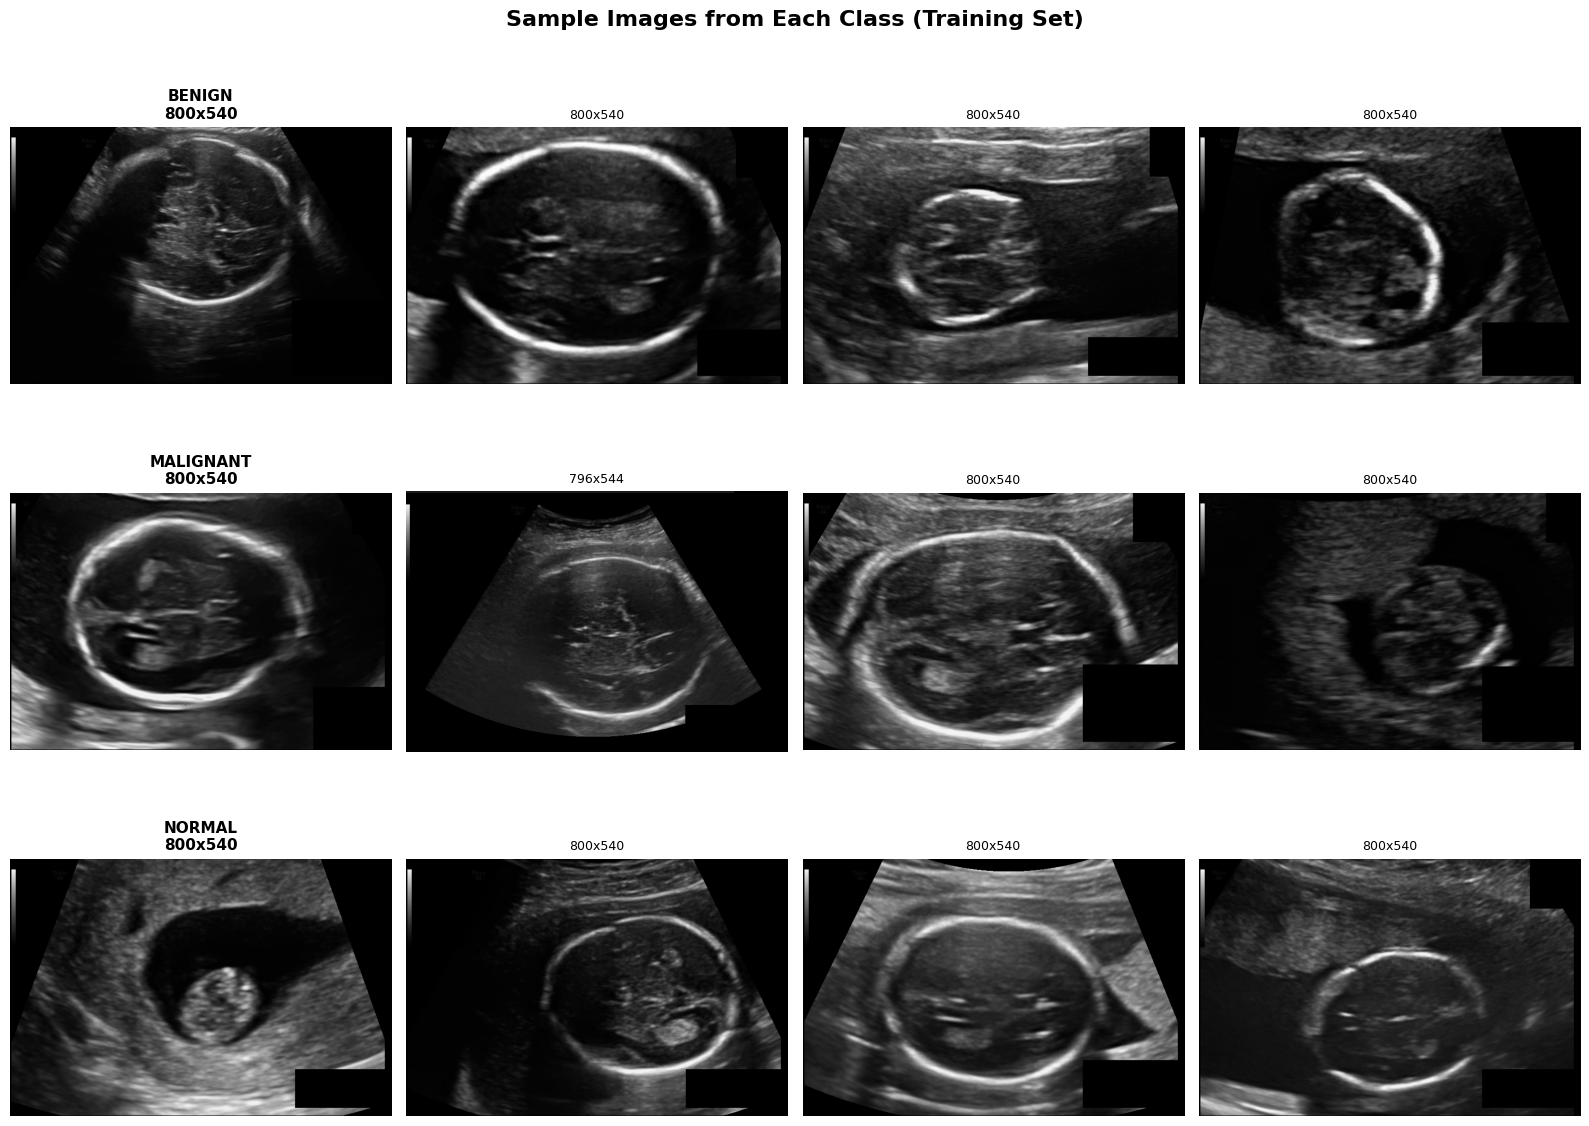

In [ ]:


def visualize_samples(dataset_info, samples_per_class=4):

    classes = dataset_info['classes']
    num_classes = len(classes)
    
    fig, axes = plt.subplots(num_classes, samples_per_class, 
                             figsize=(16, 4 * num_classes))
    
    if num_classes == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle('Sample Images from Each Class (Training Set)', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    for row, class_name in enumerate(classes):
        # Get paths for this class from training set
        class_idx = dataset_info['class_to_idx'][class_name]
        class_paths = [path for path, label in zip(dataset_info['train']['paths'], 
                                                     dataset_info['train']['labels']) 
                       if label == class_idx]
        
        # Sample random images
        num_samples = min(samples_per_class, len(class_paths))
        sample_paths = np.random.choice(class_paths, num_samples, replace=False)
        
        for col, img_path in enumerate(sample_paths):
            try:
                img = Image.open(img_path).convert('RGB')
                axes[row, col].imshow(img)
                axes[row, col].axis('off')
                
                if col == 0:
                    axes[row, col].set_title(f'{class_name.upper()}\n{img.size[0]}x{img.size[1]}', 
                                            fontsize=11, fontweight='bold')
                else:
                    axes[row, col].set_title(f'{img.size[0]}x{img.size[1]}', fontsize=9)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
                axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['save_dir'], 'sample_images.png'), 
                dpi=150, bbox_inches='tight')
    plt.show()

visualize_samples(dataset_info, samples_per_class=4)

In [ ]:


class UltrasoundDataset(Dataset):

    def __init__(self, image_paths, labels, transform=None):

        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # Load image
        img_path = self.image_paths[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a blank image if loading fails
            image = Image.new('RGB', (CONFIG['img_size'], CONFIG['img_size']), color='black')
        
        label = self.labels[idx]
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, label

print("✓ Custom Dataset class defined!")

✓ Custom Dataset class defined!


In [ ]:


# Standard training transforms
train_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Aggressive augmentation for oversampled images
if CONFIG['use_aggressive_augmentation']:
    aggressive_transform = transforms.Compose([
        transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),  # Increased
        transforms.RandomRotation(degrees=25),  # Increased
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
        transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.85, 1.15)),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
else:
    aggressive_transform = train_transform

# Validation/Test transforms (no augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("=" * 80)
print("DATA TRANSFORMS")
print("=" * 80)
print("\nTraining augmentations:")
print("  ✓ Resize to", CONFIG['img_size'])
print("  ✓ Random horizontal flip")
print("  ✓ Random vertical flip")
print("  ✓ Random rotation (±15°)")
print("  ✓ Color jitter (brightness & contrast)")
print("  ✓ Random affine transformation")
print("  ✓ Normalization (ImageNet stats)")


# Use aggressive transform if enabled, otherwise standard
active_train_transform = aggressive_transform if CONFIG['use_aggressive_augmentation'] else train_transform
print(f"\nUsing {'AGGRESSIVE' if CONFIG['use_aggressive_augmentation'] else 'STANDARD'} augmentation for training")

# Create datasets
train_dataset = UltrasoundDataset(
    dataset_info['train']['paths'],
    dataset_info['train']['labels'],
    transform=active_train_transform
)

val_dataset = UltrasoundDataset(
    dataset_info['val']['paths'],
    dataset_info['val']['labels'],
    transform=val_test_transform
)

test_dataset = UltrasoundDataset(
    dataset_info['test']['paths'],
    dataset_info['test']['labels'],
    transform=val_test_transform
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    pin_memory=CONFIG['pin_memory']
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=CONFIG['pin_memory']
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=CONFIG['pin_memory']
)

print("=" * 80)
print("DATALOADERS CREATED")
print("=" * 80)

print(f"Train batches: {len(train_loader)} (Total: {len(train_dataset)} images)")
print(f"\nBatch size: {CONFIG['batch_size']}")

print(f"Val batches:   {len(val_loader)} (Total: {len(val_dataset)} images)")
print(f"Test batches:  {len(test_loader)} (Total: {len(test_dataset)} images)")

DATA TRANSFORMS

Training augmentations:
  ✓ Resize to 224
  ✓ Random horizontal flip
  ✓ Random vertical flip
  ✓ Random rotation (±15°)
  ✓ Color jitter (brightness & contrast)
  ✓ Random affine transformation
  ✓ Normalization (ImageNet stats)

Using STANDARD augmentation for training
DATALOADERS CREATED
Train batches: 134 (Total: 2129 images)

Batch size: 16
Val batches:   13 (Total: 208 images)
Test batches:  16 (Total: 249 images)


In [ ]:


class MobileNetUltrasound(nn.Module):

    def __init__(self, num_classes=3, pretrained_path=None, freeze_backbone=False):
        super(MobileNetUltrasound, self).__init__()
        
        # Load pretrained MobileNetV2
        print("\n📦 Loading MobileNetV2 with ImageNet weights...")
        self.mobilenet = models.mobilenet_v2(pretrained=True)
        print("✓ MobileNetV2 loaded!")
        
        # Get number of features
        num_features = self.mobilenet.classifier[1].in_features
        
        # Replace classifier with higher dropout (to combat overfitting)
        self.mobilenet.classifier = nn.Sequential(
            nn.Dropout(0.5),  # Higher dropout
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
        
        # Freeze backbone if requested
        if freeze_backbone:
            print("\n🔒 Freezing backbone layers")
            for name, param in self.mobilenet.named_parameters():
                if 'classifier' not in name:
                    param.requires_grad = False
    
    def forward(self, x):
        return self.mobilenet(x)

# Initialize model
print("=" * 80)
print("MODEL INITIALIZATION")
print("=" * 80)

model = MobileNetUltrasound(
    num_classes=CONFIG['num_classes'],
    pretrained_path=CONFIG['pretrained_model_path'],
    freeze_backbone=CONFIG['freeze_backbone']
).to(device)

print(f"\nModel: MobileNetV2")
print(f"Number of classes: {CONFIG['num_classes']}")
print(f"Classes: {CONFIG['classes']}")
print(f"Device: {device}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

# Test forward pass
dummy_input = torch.randn(2, 3, CONFIG['img_size'], CONFIG['img_size']).to(device)
with torch.no_grad():
    dummy_output = model(dummy_input)
print(f"\nTest forward pass:")
print(f"  Input shape: {dummy_input.shape}")
print(f"  Output shape: {dummy_output.shape}")
print(f"✓ Model architecture verified successfully!")

MODEL INITIALIZATION

📦 Loading MobileNetV2 with ImageNet weights...
✓ MobileNetV2 loaded!

Model: MobileNetV2
Number of classes: 3
Classes: ['benign', 'malignant', 'normal']
Device: cuda

Total parameters: 2,552,579
Trainable parameters: 2,552,579
Frozen parameters: 0

Test forward pass:
  Input shape: torch.Size([2, 3, 224, 224])
  Output shape: torch.Size([2, 3])
✓ Model architecture verified successfully!


In [ ]:


# # Calculate class weights - BUT CLIP THEM
# train_labels = dataset_info['train']['labels']
# class_counts = np.bincount(train_labels, minlength=CONFIG['num_classes'])

# # Less aggressive weighting
# class_weights = 1.0 / (class_counts + 1e-6)
# class_weights = class_weights / class_weights.sum() * CONFIG['num_classes']

# # CLIP weights to prevent extremes
# class_weights = np.clip(class_weights, 0.5, 2.0)  # NEW: Limit range
# class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("=" * 80)
print("TRAINING SETUP")
print("=" * 80)
print("\n⚠️  Using UNWEIGHTED loss (no class balancing in loss)")

# print("\nClass weights (for handling imbalance):")
# for idx, cls in enumerate(CONFIG['classes']):
#     print(f"  {cls}: {class_weights[idx]:.4f} (count: {class_counts[idx]})")

# Loss function with class weights
# criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Loss function with Label Smoothing (prevents overconfident predictions)
criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG.get('label_smoothing', 0.1))

# Optimizer - use different learning rates for backbone and classifier
if CONFIG['freeze_backbone']:
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CONFIG['learning_rate'],
        weight_decay=CONFIG['weight_decay']
    )
else:
    optimizer = optim.AdamW([
        {'params': model.mobilenet.classifier.parameters(), 'lr': CONFIG['learning_rate']},
        {'params': [p for n, p in model.mobilenet.named_parameters() if 'classifier' not in n], 
         'lr': CONFIG['learning_rate'] * 0.1}
    ], weight_decay=CONFIG['weight_decay'])

# CosineAnnealingWarmRestarts - better than ReduceLROnPlateau for small datasets
# Periodically resets LR to escape local minima and explore the loss surface
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,       # Restart every 10 epochs
    T_mult=2,     # Double the period after each restart
    eta_min=1e-6  # Minimum learning rate
)

# Mixed precision scaler
scaler = torch.cuda.amp.GradScaler() if CONFIG['use_amp'] else None

print(f"\nLoss: CrossEntropyLoss (label_smoothing={CONFIG.get('label_smoothing', 0.1)})")
print(f"Optimizer: AdamW")
print(f"Learning rate: {CONFIG['learning_rate']} (classifier), {CONFIG['learning_rate']*0.1} (backbone)")
print(f"Weight decay: {CONFIG['weight_decay']}")
print(f"LR Scheduler: CosineAnnealingWarmRestarts (T_0=10, T_mult=2)")
print(f"MixUp alpha: {CONFIG.get('mixup_alpha', 0.3)}")
print(f"Mixed Precision: {CONFIG['use_amp']}")

TRAINING SETUP

⚠️  Using UNWEIGHTED loss (no class balancing in loss)

Loss: CrossEntropyLoss (label_smoothing=0.1)
Optimizer: AdamW
Learning rate: 0.001 (classifier), 0.0001 (backbone)
Weight decay: 0.0001
LR Scheduler: CosineAnnealingWarmRestarts (T_0=10, T_mult=2)
MixUp alpha: 0.3
Mixed Precision: True


In [ ]:


from tqdm import tqdm

def train_epoch(model, loader, criterion, optimizer, scaler, device):

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training', leave=False)
    
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision training
        if scaler:
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100 * correct / total:.2f}%'
        })
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

def validate_epoch(model, loader, criterion, device):

    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    pbar = tqdm(loader, desc='Validation', leave=False)
    
    with torch.no_grad():
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Get probabilities
            probs = torch.softmax(outputs, dim=1)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100 * correct / total:.2f}%'
            })
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs

print("✓ Training and validation functions defined!")

✓ Training and validation functions defined!


In [ ]:


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, scaler, 
                num_epochs, patience, device, save_path):

    print("\n" + "=" * 80)
    print("STARTING TRAINING")
    print("=" * 80)
    
    best_val_acc = 0.0
    best_val_loss = float('inf')
    patience_counter = 0
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'lr': []
    }
    
    for epoch in range(num_epochs):
        print(f"\n{'='*80}")
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"{'='*80}")
        
        # Training
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, scaler, device)
        
        # Validation
        val_loss, val_acc, _, _, _ = validate_epoch(model, val_loader, criterion, device)
        
        # Update learning rate (CosineAnnealing steps per epoch, no val_loss needed)
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        
        # Print epoch summary
        print(f"\n📊 Epoch {epoch+1} Summary:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        print(f"  Learning Rate: {current_lr:.2e}")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            patience_counter = 0
            
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_loss': val_loss,
                'train_acc': train_acc,
                'train_loss': train_loss,
                'config': CONFIG,
                'class_to_idx': dataset_info['class_to_idx'],
                'idx_to_class': dataset_info['idx_to_class']
            }, os.path.join(save_path, 'best_model.pth'))
            
            print(f"  ✓ New best model saved! (Val Acc: {val_acc:.2f}%)")
        else:
            patience_counter += 1
            print(f"  No improvement for {patience_counter} epoch(s). Patience: {patience_counter}/{patience}")
        
        # Early stopping
        if patience_counter >= patience:
            print(f"\n⚠️  Early stopping triggered after {epoch+1} epochs")
            print(f"   Best validation accuracy: {best_val_acc:.2f}%")
            break
    
    print("\n" + "=" * 80)
    print("TRAINING COMPLETED")
    print("=" * 80)
    print(f"✓ Best Validation Accuracy: {best_val_acc:.2f}%")
    print(f"✓ Best Validation Loss: {best_val_loss:.4f}")
    print(f"✓ Total epochs trained: {epoch+1}")
    
    # Save final model and history
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
        'config': CONFIG
    }, os.path.join(save_path, 'final_model.pth'))
    
    with open(os.path.join(save_path, 'training_history.json'), 'w') as f:
        json.dump(history, f, indent=2)
    
    return history

# Start training
print("\n🚀 Starting training process...")
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    num_epochs=CONFIG['num_epochs'],
    patience=CONFIG['patience'],
    device=device,
    save_path=CONFIG['model_save_path']
)

# Update CONFIG with class mappings
CONFIG['class_to_idx'] = dataset_info['class_to_idx']
CONFIG['idx_to_class'] = dataset_info['idx_to_class']


🚀 Starting training process...

STARTING TRAINING

Epoch [1/50]



📊 Epoch 1 Summary:
  Train Loss: 1.1342 | Train Acc: 34.34%
  Val Loss:   1.1390 | Val Acc:   22.12%
  Learning Rate: 9.76e-04
  ✓ New best model saved! (Val Acc: 22.12%)

Epoch [2/50]



📊 Epoch 2 Summary:
  Train Loss: 1.0956 | Train Acc: 37.48%
  Val Loss:   1.0999 | Val Acc:   38.46%
  Learning Rate: 9.05e-04
  ✓ New best model saved! (Val Acc: 38.46%)

Epoch [3/50]



📊 Epoch 3 Summary:
  Train Loss: 1.0897 | Train Acc: 38.37%
  Val Loss:   1.0767 | Val Acc:   48.08%
  Learning Rate: 7.94e-04
  ✓ New best model saved! (Val Acc: 48.08%)

Epoch [4/50]



📊 Epoch 4 Summary:
  Train Loss: 1.0828 | Train Acc: 40.07%
  Val Loss:   1.0840 | Val Acc:   42.79%
  Learning Rate: 6.55e-04
  No improvement for 1 epoch(s). Patience: 1/15

Epoch [5/50]


...


📊 Epoch 39 Summary:
  Train Loss: 0.7608 | Train Acc: 68.81%
  Val Loss:   1.2533 | Val Acc:   41.35%
  Learning Rate: 8.80e-04
  No improvement for 11 epoch(s). Patience: 11/15

Epoch [40/50]



📊 Epoch 40 Summary:
  Train Loss: 0.7347 | Train Acc: 70.60%
  Val Loss:   1.3805 | Val Acc:   37.50%
  Learning Rate: 8.54e-04
  No improvement for 12 epoch(s). Patience: 12/15

Epoch [41/50]



📊 Epoch 41 Summary:
  Train Loss: 0.7200 | Train Acc: 72.19%
  Val Loss:   1.2219 | Val Acc:   49.52%
  Learning Rate: 8.25e-04
  No improvement for 13 epoch(s). Patience: 13/15

Epoch [42/50]



📊 Epoch 42 Summary:
  Train Loss: 0.7230 | Train Acc: 71.77%
  Val Loss:   1.1721 | Val Acc:   54.33%
  Learning Rate: 7.94e-04
  No improvement for 14 epoch(s). Patience: 14/15

Epoch [43/50]



📊 Epoch 43 Summary:
  Train Loss: 0.7253 | Train Acc: 72.15%
  Val Loss:   1.2259 | Val Acc:   48.08%
  Learning Rate: 7.61e-04
  No improvement for 15 epoch(s). Patience: 15/15

⚠️  Early stopping triggered after 43 epochs
   Best validation accuracy: 58.17%

TRAINING COMPLETED
✓ Best Validation Accuracy: 58.17%
✓ Best Validation Loss: 1.0415
✓ Total epochs trained: 43


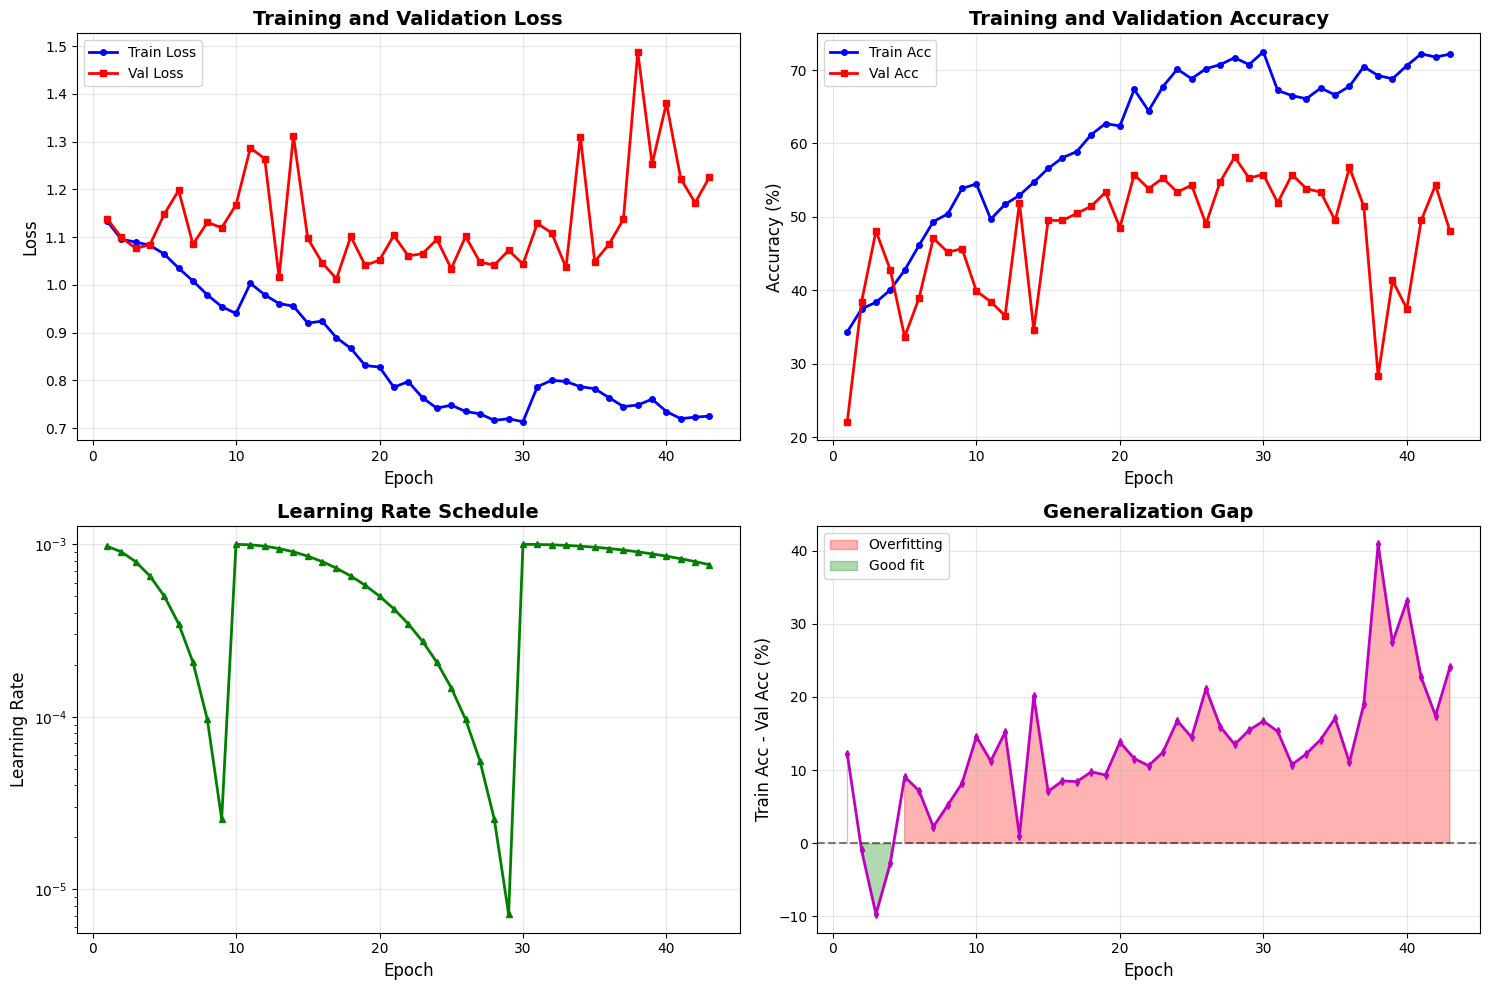

In [ ]:


def plot_training_history(history, save_path):

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss curves
    axes[0, 0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=4)
    axes[0, 0].plot(epochs, history['val_loss'], 'r-s', label='Val Loss', linewidth=2, markersize=4)
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(alpha=0.3)
    
    # Accuracy curves
    axes[0, 1].plot(epochs, history['train_acc'], 'b-o', label='Train Acc', linewidth=2, markersize=4)
    axes[0, 1].plot(epochs, history['val_acc'], 'r-s', label='Val Acc', linewidth=2, markersize=4)
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[0, 1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(alpha=0.3)
    
    # Learning rate
    axes[1, 0].plot(epochs, history['lr'], 'g-^', linewidth=2, markersize=4)
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('Learning Rate', fontsize=12)
    axes[1, 0].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[1, 0].set_yscale('log')
    axes[1, 0].grid(alpha=0.3)
    
    # Overfitting indicator
    gap = np.array(history['train_acc']) - np.array(history['val_acc'])
    axes[1, 1].plot(epochs, gap, 'm-d', linewidth=2, markersize=4)
    axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5, linewidth=1.5)
    axes[1, 1].fill_between(epochs, 0, gap, where=(gap>0), alpha=0.3, color='red', label='Overfitting')
    axes[1, 1].fill_between(epochs, 0, gap, where=(gap<=0), alpha=0.3, color='green', label='Good fit')
    axes[1, 1].set_xlabel('Epoch', fontsize=12)
    axes[1, 1].set_ylabel('Train Acc - Val Acc (%)', fontsize=12)
    axes[1, 1].set_title('Generalization Gap', fontsize=14, fontweight='bold')
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, 'training_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(history, CONFIG['save_dir'])


LOADING BEST MODEL FOR EVALUATION
✓ Best model loaded from epoch: 28
  Validation accuracy: 58.17%
  Validation loss: 1.0415

EVALUATING ON TEST SET



📊 TEST SET RESULTS:
  Test Loss: 1.1105
  Test Accuracy: 52.21%

CLASSIFICATION REPORT - TEST SET

              precision    recall  f1-score   support

      benign     0.0400    0.0392    0.0396        51
   malignant     0.8188    0.8243    0.8215       148
      normal     0.1200    0.1200    0.1200        50

    accuracy                         0.5221       249
   macro avg     0.3263    0.3278    0.3271       249
weighted avg     0.5190    0.5221    0.5205       249


PER-CLASS METRICS
Class           Precision    Recall       F1-Score     Support     
--------------------------------------------------------------------------------
benign          0.0400       0.0392       0.0396       51          
malignant       0.8188       0.8243       0.8215       148         
normal          0.1200       0.1200       0.1200       50          

OVERALL         0.3263       0.3278       0.3271       249         


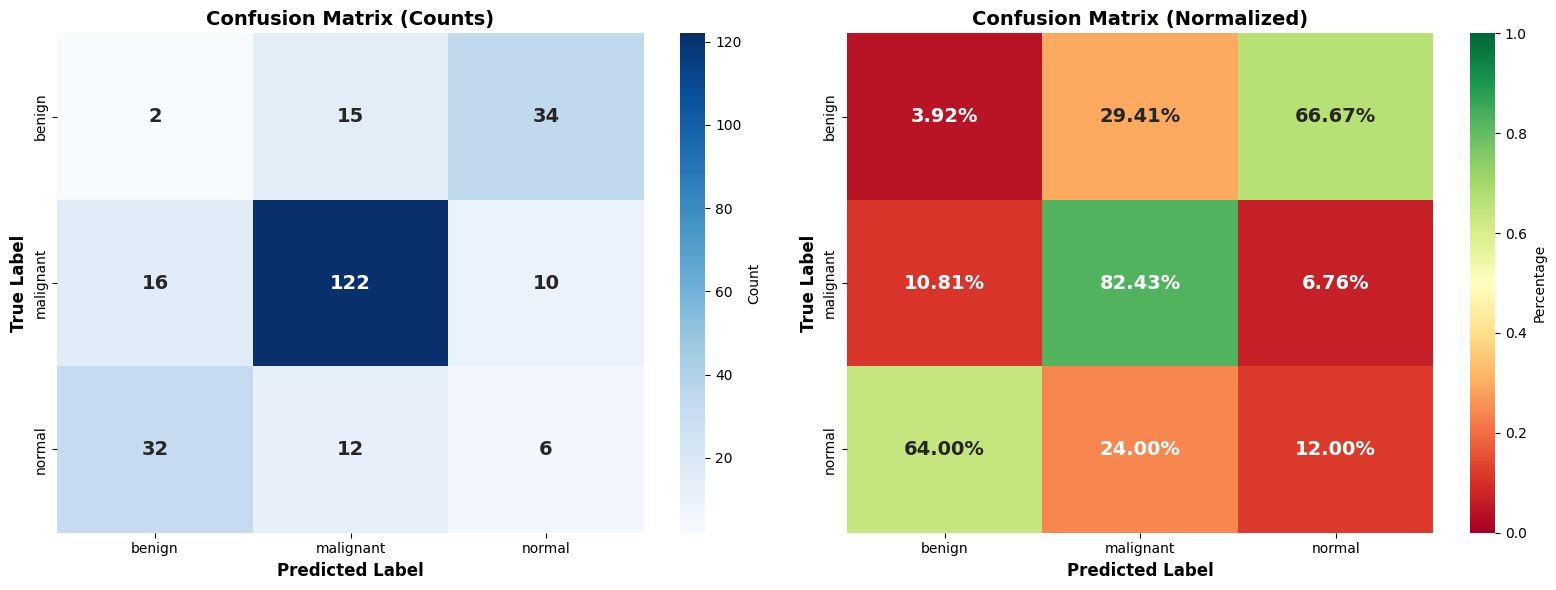


MISCLASSIFICATION ANALYSIS
15 benign samples misclassified as malignant (29.4%)
34 benign samples misclassified as normal (66.7%)
16 malignant samples misclassified as benign (10.8%)
10 malignant samples misclassified as normal (6.8%)
32 normal samples misclassified as benign (64.0%)
12 normal samples misclassified as malignant (24.0%)


In [ ]:


print("\n" + "=" * 80)
print("LOADING BEST MODEL FOR EVALUATION")
print("=" * 80)

# Load best model
checkpoint = torch.load(os.path.join(CONFIG['model_save_path'], 'best_model.pth'))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✓ Best model loaded from epoch: {checkpoint['epoch']}")
print(f"  Validation accuracy: {checkpoint['val_acc']:.2f}%")
print(f"  Validation loss: {checkpoint['val_loss']:.4f}")

# Evaluate on test set
print(f"\n{'='*80}")
print("EVALUATING ON TEST SET")
print(f"{'='*80}")

test_loss, test_acc, test_preds, test_labels, test_probs = validate_epoch(
    model, test_loader, criterion, device
)

print(f"\n📊 TEST SET RESULTS:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.2f}%")

print("\n" + "=" * 80)
print("CLASSIFICATION REPORT - TEST SET")
print("=" * 80)

# Classification report
report = classification_report(
    test_labels, 
    test_preds, 
    target_names=CONFIG['classes'],
    digits=4
)
print("\n" + report)

# Save report
with open(os.path.join(CONFIG['save_dir'], 'classification_report.txt'), 'w') as f:
    f.write("FETAL HEALTH CLASSIFICATION - TEST SET RESULTS\n")
    f.write("=" * 80 + "\n\n")
    f.write(f"Test Accuracy: {test_acc:.2f}%\n")
    f.write(f"Test Loss: {test_loss:.4f}\n\n")
    f.write(report)

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    test_labels, test_preds, average=None
)

print("\n" + "=" * 80)
print("PER-CLASS METRICS")
print("=" * 80)
print(f"{'Class':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<12}")
print("-" * 80)
for idx, cls in enumerate(CONFIG['classes']):
    print(f"{cls:<15} {precision[idx]:<12.4f} {recall[idx]:<12.4f} {f1[idx]:<12.4f} {int(support[idx]):<12}")

# Overall metrics
print(f"\n{'OVERALL':<15} {np.mean(precision):<12.4f} {np.mean(recall):<12.4f} {np.mean(f1):<12.4f} {int(np.sum(support)):<12}")


# Compute confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Plot raw confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CONFIG['classes'], 
            yticklabels=CONFIG['classes'],
            cbar_kws={'label': 'Count'},
            ax=axes[0],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# Normalized (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn',
            xticklabels=CONFIG['classes'],
            yticklabels=CONFIG['classes'],
            cbar_kws={'label': 'Percentage'},
            ax=axes[1],
            annot_kws={'size': 14, 'weight': 'bold'},
            vmin=0, vmax=1)
axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['save_dir'], 'confusion_matrix.png'), 
            dpi=150, bbox_inches='tight')
plt.show()

# Print misclassification analysis
print("\n" + "=" * 80)
print("MISCLASSIFICATION ANALYSIS")
print("=" * 80)
for i, true_class in enumerate(CONFIG['classes']):
    for j, pred_class in enumerate(CONFIG['classes']):
        if i != j and cm[i, j] > 0:
            percentage = (cm[i, j] / cm[i].sum()) * 100
            print(f"{cm[i, j]} {true_class} samples misclassified as {pred_class} ({percentage:.1f}%)")


INITIALIZING GRAD-CAM
✓ Grad-CAM visualizer initialized!
  Target layer: Conv2dNormActivation(
  (0): Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU6(inplace=True)
)

GENERATING GRAD-CAM VISUALIZATIONS


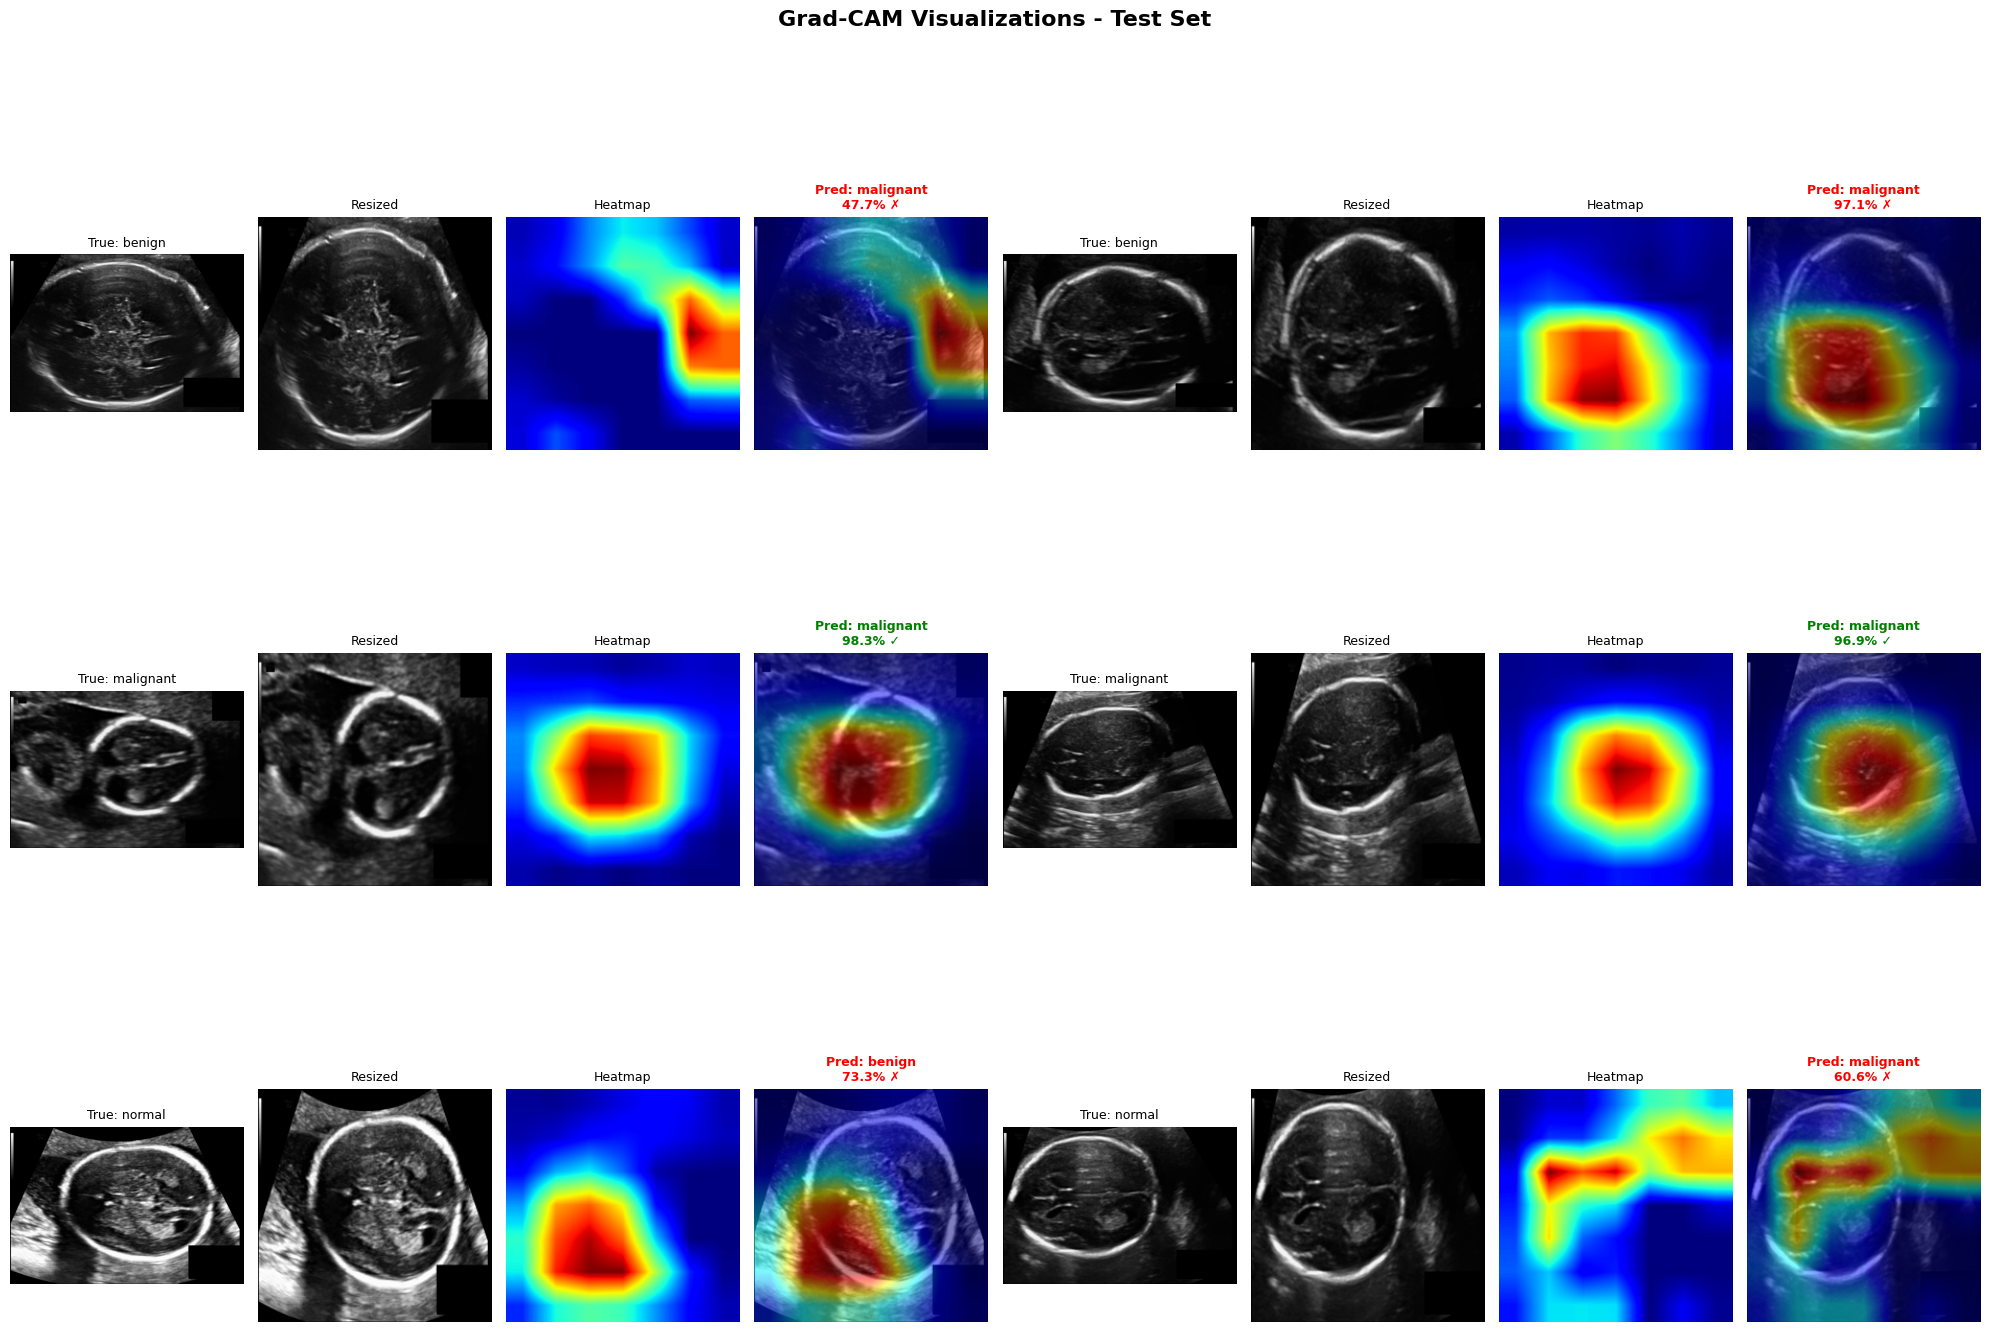

In [ ]:


class GradCAMVisualizer:

    def __init__(self, model, device):
        self.model = model
        self.device = device
        # Target the last convolutional layer of MobileNetV2
        self.target_layer = model.mobilenet.features[-1]
        self.cam = GradCAM(model=model, target_layers=[self.target_layer])
    
    def generate_cam(self, input_tensor, target_class=None):
        """
        Generate Grad-CAM heatmap
        """
        # If no target class specified, use predicted class
        if target_class is None:
            with torch.no_grad():
                output = self.model(input_tensor)
                target_class = output.argmax(dim=1).item()
        
        # Generate CAM
        targets = [ClassifierOutputTarget(target_class)]
        grayscale_cam = self.cam(input_tensor=input_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0, :]
        
        return grayscale_cam, target_class
    
    def visualize_single(self, image_path, true_label_idx=None, save_path=None):
        """
        Visualize Grad-CAM for a single image
        """
        # Load and preprocess image
        img = Image.open(image_path).convert('RGB')
        img_tensor = val_test_transform(img).unsqueeze(0).to(self.device)
        
        # Get prediction
        with torch.no_grad():
            output = self.model(img_tensor)
            probabilities = torch.softmax(output, dim=1)[0]
            predicted_class = output.argmax(dim=1).item()
            confidence = probabilities[predicted_class].item()
        
        # Generate CAM
        grayscale_cam, _ = self.generate_cam(img_tensor, target_class=predicted_class)
        
        # Prepare image for visualization
        img_resized = img.resize((CONFIG['img_size'], CONFIG['img_size']))
        img_array = np.array(img_resized) / 255.0
        
        # Overlay CAM
        visualization = show_cam_on_image(img_array, grayscale_cam, use_rgb=True)
        
        # Create figure
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Original
        axes[0].imshow(img)
        axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
        axes[0].axis('off')
        
        # Heatmap
        axes[1].imshow(grayscale_cam, cmap='jet')
        axes[1].set_title('Grad-CAM Heatmap', fontsize=12, fontweight='bold')
        axes[1].axis('off')
        
        # Overlay
        axes[2].imshow(visualization)
        predicted_label = CONFIG['classes'][predicted_class]
        
        title = f'Prediction: {predicted_label}\nConfidence: {confidence:.1%}'
        if true_label_idx is not None:
            true_label = CONFIG['classes'][true_label_idx]
            is_correct = (predicted_class == true_label_idx)
            title += f'\nTrue: {true_label} {"✓" if is_correct else "✗"}'
            axes[2].set_title(title, fontsize=12, fontweight='bold',
                            color='green' if is_correct else 'red')
        else:
            axes[2].set_title(title, fontsize=12, fontweight='bold')
        axes[2].axis('off')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        
        return predicted_class, confidence, grayscale_cam

# Initialize Grad-CAM
print("\n" + "=" * 80)
print("INITIALIZING GRAD-CAM")
print("=" * 80)

gradcam_viz = GradCAMVisualizer(model, device)
print(f"✓ Grad-CAM visualizer initialized!")
print(f"  Target layer: {gradcam_viz.target_layer}")



def visualize_gradcam_per_class(model, gradcam_viz, dataset_info, split='test', 
                                samples_per_class=2, save_dir=None):

    classes = CONFIG['classes']
    num_classes = len(classes)
    
    fig, axes = plt.subplots(num_classes, samples_per_class * 4, 
                             figsize=(20, 5 * num_classes))
    
    if num_classes == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle(f'Grad-CAM Visualizations - {split.capitalize()} Set', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    for class_idx, class_name in enumerate(classes):
        # Get paths for this class
        class_paths = [path for path, label in zip(dataset_info[split]['paths'], 
                                                     dataset_info[split]['labels']) 
                       if label == class_idx]
        
        # Sample random images
        num_samples = min(samples_per_class, len(class_paths))
        if num_samples > 0:
            sample_paths = np.random.choice(class_paths, num_samples, replace=False)
        else:
            sample_paths = []
        
        for sample_idx, img_path in enumerate(sample_paths):
            # Load image
            img = Image.open(img_path).convert('RGB')
            img_tensor = val_test_transform(img).unsqueeze(0).to(device)
            
            # Get prediction
            with torch.no_grad():
                output = model(img_tensor)
                probabilities = torch.softmax(output, dim=1)[0]
                predicted_class = output.argmax(dim=1).item()
                confidence = probabilities[predicted_class].item()
            
            predicted_label = CONFIG['classes'][predicted_class]
            
            # Generate CAM
            grayscale_cam, _ = gradcam_viz.generate_cam(img_tensor, target_class=predicted_class)
            
            # Prepare visualization
            img_resized = img.resize((CONFIG['img_size'], CONFIG['img_size']))
            img_array = np.array(img_resized) / 255.0
            visualization = show_cam_on_image(img_array, grayscale_cam, use_rgb=True)
            
            # Plot
            col_offset = sample_idx * 4
            
            # Original
            axes[class_idx, col_offset].imshow(img)
            axes[class_idx, col_offset].set_title(f'True: {class_name}', fontsize=9)
            axes[class_idx, col_offset].axis('off')
            
            # Resized
            axes[class_idx, col_offset + 1].imshow(img_resized)
            axes[class_idx, col_offset + 1].set_title('Resized', fontsize=9)
            axes[class_idx, col_offset + 1].axis('off')
            
            # Heatmap
            axes[class_idx, col_offset + 2].imshow(grayscale_cam, cmap='jet')
            axes[class_idx, col_offset + 2].set_title('Heatmap', fontsize=9)
            axes[class_idx, col_offset + 2].axis('off')
            
            # Overlay
            axes[class_idx, col_offset + 3].imshow(visualization)
            is_correct = (predicted_class == class_idx)
            status = "✓" if is_correct else "✗"
            color = 'green' if is_correct else 'red'
            axes[class_idx, col_offset + 3].set_title(
                f'Pred: {predicted_label}\n{confidence:.1%} {status}', 
                fontsize=9, color=color, fontweight='bold'
            )
            axes[class_idx, col_offset + 3].axis('off')
    
    plt.tight_layout()
    
    if save_dir:
        plt.savefig(os.path.join(save_dir, 'gradcam_test_samples.png'), 
                   dpi=150, bbox_inches='tight')
    plt.show()

print("\n" + "=" * 80)
print("GENERATING GRAD-CAM VISUALIZATIONS")
print("=" * 80)

visualize_gradcam_per_class(model, gradcam_viz, dataset_info, split='test', 
                           samples_per_class=2, save_dir=CONFIG['save_dir'])

In [ ]:


# Compile summary
summary = {
    'model_architecture': 'ResNet50',
    'pretrained_from': CONFIG['pretrained_model_path'],
    'num_classes': CONFIG['num_classes'],
    'classes': CONFIG['classes'],
    
    # Dataset info
    'total_images': (len(dataset_info['train']['paths']) + 
                    len(dataset_info['val']['paths']) + 
                    len(dataset_info['test']['paths'])),
    'train_size': len(dataset_info['train']['paths']),
    'val_size': len(dataset_info['val']['paths']),
    'test_size': len(dataset_info['test']['paths']),
    'class_balanced': CONFIG['balance_classes'],
    'aggressive_augmentation': CONFIG['use_aggressive_augmentation'],
    
    # Training info
    'total_epochs_trained': checkpoint['epoch'],
    'best_val_acc': float(checkpoint['val_acc']),
    'best_val_loss': float(checkpoint['val_loss']),
    
    # Test results
    'test_acc': float(test_acc),
    'test_loss': float(test_loss),
    
    # Per-class results
    'per_class_precision': {CONFIG['classes'][i]: float(precision[i]) for i in range(len(CONFIG['classes']))},
    'per_class_recall': {CONFIG['classes'][i]: float(recall[i]) for i in range(len(CONFIG['classes']))},
    'per_class_f1': {CONFIG['classes'][i]: float(f1[i]) for i in range(len(CONFIG['classes']))},
    
    # Training config
    'img_size': CONFIG['img_size'],
    'batch_size': CONFIG['batch_size'],
    'learning_rate': CONFIG['learning_rate'],
    'optimizer': 'AdamW',
    'loss_function': 'CrossEntropyLoss (weighted)',
}

# Save summary
with open(os.path.join(CONFIG['save_dir'], 'model_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

# Print final summary
print("\n" + "=" * 80)
print("FINAL SUMMARY - MODEL 1 (ULTRASOUND IMAGES)")
print("=" * 80)
print("\n📊 Dataset:")
print(f"  Total images: {summary['total_images']}")
print(f"  Train/Val/Test: {summary['train_size']}/{summary['val_size']}/{summary['test_size']}")

print("\n🎯 Best Model Performance:")
print(f"  Validation Accuracy: {summary['best_val_acc']:.2f}%")
print(f"  Test Accuracy: {summary['test_acc']:.2f}%")

print("\n📈 Per-Class Results:")
for cls in CONFIG['classes']:
    print(f"  {cls.capitalize()}:")
    print(f"    Precision: {summary['per_class_precision'][cls]:.4f}")
    print(f"    Recall: {summary['per_class_recall'][cls]:.4f}")
    print(f"    F1-Score: {summary['per_class_f1'][cls]:.4f}")

print("\n💾 Saved Files:")
print(f"  ✓ Best model: {CONFIG['model_save_path']}/best_model.pth")
print(f"  ✓ Final model: {CONFIG['model_save_path']}/final_model.pth")
print(f"  ✓ Training history: {CONFIG['model_save_path']}/training_history.json")
print(f"  ✓ Model summary: {CONFIG['save_dir']}/model_summary.json")
print(f"  ✓ Classification report: {CONFIG['save_dir']}/classification_report.txt")
print(f"  ✓ Visualizations: {CONFIG['save_dir']}/*.png")

print("\n" + "=" * 80)
print("✅ MODEL 1 TRAINING COMPLETE!")
print("=" * 80)
print("\n🎉 Your fetal health classification model is ready!")
print(f"📁 All outputs saved to: {CONFIG['save_dir']}/")
print("\n💡 Next steps:")
print("  1. Review the Grad-CAM visualizations to understand model focus")
print("  2. Check malignant cases analysis for clinical relevance")
print("  3. Consider fine-tuning if specific classes need improvement")
print("  4. Ready to train Model 2 on the second dataset!")
print("\n" + "=" * 80)


FINAL SUMMARY - MODEL 1 (ULTRASOUND IMAGES)

📊 Dataset:
  Total images: 2586
  Train/Val/Test: 2129/208/249

🎯 Best Model Performance:
  Validation Accuracy: 58.17%
  Test Accuracy: 52.21%

📈 Per-Class Results:
  Benign:
    Precision: 0.0400
    Recall: 0.0392
    F1-Score: 0.0396
  Malignant:
    Precision: 0.8188
    Recall: 0.8243
    F1-Score: 0.8215
  Normal:
    Precision: 0.1200
    Recall: 0.1200
    F1-Score: 0.1200

💾 Saved Files:
  ✓ Best model: ./model1_outputs/checkpoints/best_model.pth
  ✓ Final model: ./model1_outputs/checkpoints/final_model.pth
  ✓ Training history: ./model1_outputs/checkpoints/training_history.json
  ✓ Model summary: ./model1_outputs/model_summary.json
  ✓ Classification report: ./model1_outputs/classification_report.txt
  ✓ Visualizations: ./model1_outputs/*.png

✅ MODEL 1 TRAINING COMPLETE!

🎉 Your fetal health classification model is ready!
📁 All outputs saved to: ./model1_outputs/

💡 Next steps:
  1. Review the Grad-CAM visualizations to understa